In [1]:
import pandas as pd 
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm, cauchy
import numpy as np

from spurs_funcs import *

df = pd.read_parquet('/Users/laurencadle/spurs_2026/DC4_PE_week13.parquet')
energy = df['Energy'].to_numpy()
df.head(10)

,index,Time[s],Energy,xPos[cm],yPos[cm],zPos[cm],Component,Layer ID,Quadrant,Detector ID
0,2861061,0.000000,408.2790,6.06267,-3.91625,12.5477,PrimaryProtons,3,4,12
1,5974287,0.000000,93.8448,-2.43791,9.12138,17.8266,SAAprotons,1,2,6
2,30258660,0.000000,171.5220,-6.29548,8.19013,15.7887,CosmicPhotons,2,2,5
3,22992877,0.015559,154.5980,5.71345,5.97841,21.1421,CosmicPhotons,0,1,0
4,32996727,0.019003,119.0190,4.43298,8.53935,21.3424,CosmicPhotons,0,1,0
5,8176600,0.022243,186.2720,-6.41189,-4.73109,18.0495,AlbedoPhotons_PEevent,1,3,9
6,29573501,0.022504,150.2240,-8.39080,6.56044,21.1403,CosmicPhotons,0,2,7
7,33500953,0.029419,112.0660,4.78220,-2.59728,20.8777,CosmicPhotons,0,4,15
8,40312122,0.043565,127.2280,-7.92517,11.58420,20.5406,CosmicPhotons,0,2,7
9,42690504,0.048102,443.8600,2.78741,-2.40297,20.8100,CosmicPhotons,0,4,15


plot counts against time - if something doesnt pop out, then fix bins
find in anayas paper - cannot study above 1800 kev because (reason) (100-1800)

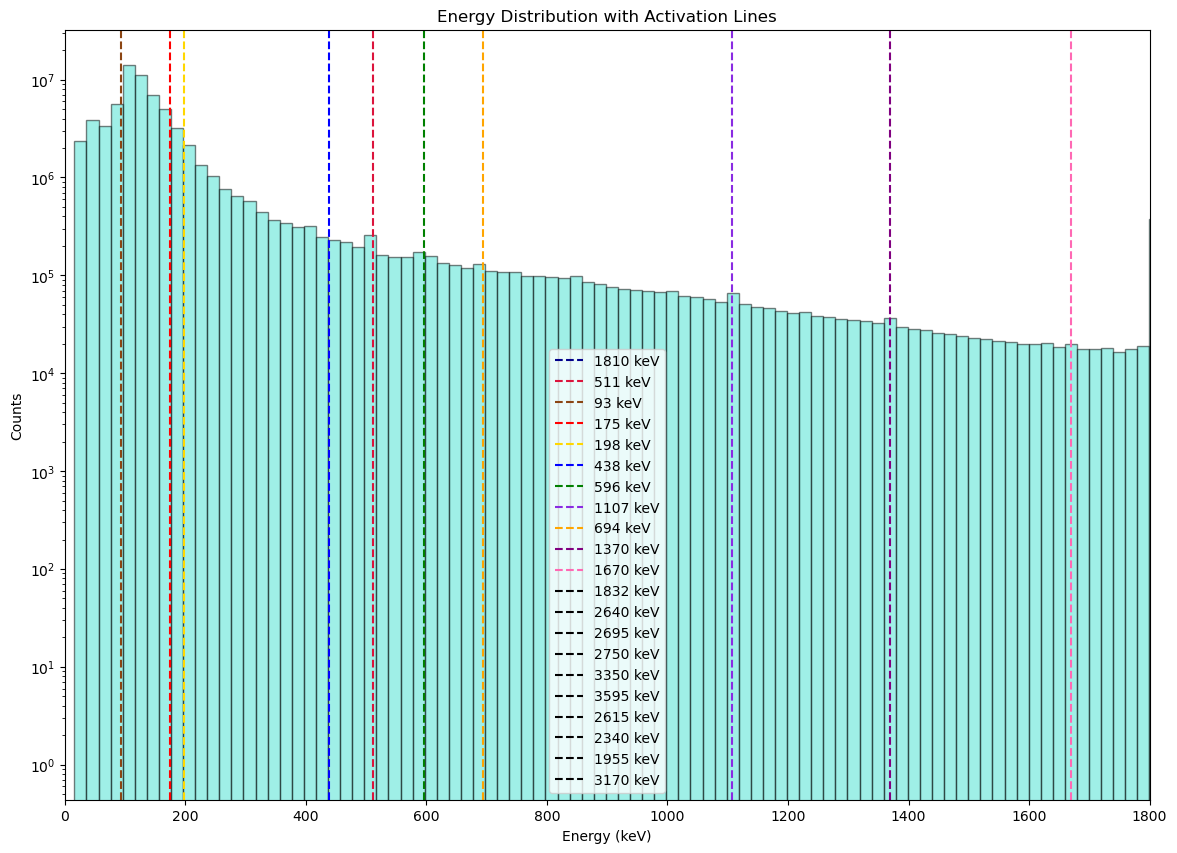

In [2]:
#whole dataset
plt.figure(figsize=(14, 10))
plt.hist(df['Energy'], bins=500, color = 'turquoise', edgecolor = 'black', alpha = 0.5)
plt.xlim((0, 1800))
plt.title('Energy Distribution with Activation Lines')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')

x1 = 93
x2 = 175
x3 = 198
x4 = 438
x5 = 596
x6 = 1107

x7 = 1810
x8 = 511
x9 = 694
x10 = 1370
x11 = 1670
x12 = 1832
x13 = 2640
x14 = 2695
x15 = 2750
x16 = 3350
x17 = 3595
x18 = 2615
x19 = 2340
x20 = 1955
x21 = 3170

plt.axvline(x=x7, color='darkblue', linestyle='--', label=f'{x7} keV')
plt.axvline(x=x8, color='crimson', linestyle='--', label=f'{x8} keV')  
plt.axvline(x=x1, color='saddlebrown', linestyle='--', label=f'{x1} keV')
plt.axvline(x=x2, color='red', linestyle='--', label=f'{x2} keV')
plt.axvline(x=x3, color='gold', linestyle='--', label=f'{x3} keV')
plt.axvline(x=x4, color='blue', linestyle='--', label=f'{x4} keV')
plt.axvline(x=x5, color='green', linestyle='--', label=f'{x5} keV')
plt.axvline(x=x6, color='blueviolet', linestyle='--', label=f'{x6} keV') 
plt.axvline(x=x9, color='orange', linestyle='--', label=f'{x9} keV')
plt.axvline(x=x10, color='purple', linestyle='--', label=f'{x10} keV')
plt.axvline(x=x11, color='hotpink', linestyle='--', label=f'{x11} keV')
plt.axvline(x=x12, color='black', linestyle='--', label=f'{x12} keV')  
plt.axvline(x=x13, color='black', linestyle='--', label=f'{x13} keV')  
plt.axvline(x=x14, color='black', linestyle='--', label=f'{x14} keV')  
plt.axvline(x=x15, color='black', linestyle='--', label=f'{x15} keV')  
plt.axvline(x=x16, color='black', linestyle='--', label=f'{x16} keV')  
plt.axvline(x=x17, color='black', linestyle='--', label=f'{x17} keV')  
plt.axvline(x=x18, color='black', linestyle='--', label=f'{x18} keV')
plt.axvline(x=x19, color='black', linestyle='--', label=f'{x19} keV')
plt.axvline(x=x20, color='black', linestyle='--', label=f'{x20} keV')
plt.axvline(x=x21, color='black', linestyle='--', label=f'{x21} keV')

plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
#ten line code!!
line = 1107
N = 200
fitting_window = 5

lower_bound, upper_bound, fitted_lower, fitted_upper= get_bounds(line, viewing_window = 15, fitting_window=fitting_window)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")
x1, fitted_model_g = plot_gaussian(line, N, p_err, counts, bin_edges, bin_centers, popt, lower_bound, upper_bound, fitted_lower, fitted_upper, fitting_window)

In [ ]:
#whole dataset
time = df['Time[s]'].to_numpy()

for bins in np.arange(100, 550, 50):
    plt.figure(figsize=(6, 4))
    plt.hist(df['Time[s]'], bins= bins, color = 'turquoise', edgecolor = 'black', alpha = 0.5)
    plt.title(f'counts vs time (bins = {bins})')
    plt.xlabel('time (s)')
    plt.ylabel('counts')

In [ ]:
#plotting saa protons on the counts vs. time graph
time = df['Time[s]'].to_numpy()
bins = 5000
bin_edges = np.linspace(0, 20000, bins)

saa_protons = df['Component'] == 'SAAprotons'
saa_counts, _ = np.histogram(df[saa_protons]['Time[s]'], bins=bin_edges)

plt.figure(figsize=(6, 4))
plt.hist(df['Time[s]'], bins=bin_edges, color = 'turquoise', alpha = 0.7)
plt.stairs(saa_counts, bin_edges, color='red', alpha=0.5, linestyle='--', label = 'saa proton counts')
plt.xlim((0, 20000))
plt.title('counts vs time with saa proton counts')
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.legend()
plt.show()

In [ ]:
#plotting cosmic photons on the counts vs. time graph
time = df['Time[s]'].to_numpy()
bins = 5000
bin_edges = np.linspace(0, 20000, bins)

cosmic_photons = df['Component'] == 'CosmicPhotons'
cospho_counts, _ = np.histogram(df[cosmic_photons]['Time[s]'], bins=bin_edges)

plt.figure(figsize=(6, 4))
plt.hist(df['Time[s]'], bins=bin_edges, color = 'turquoise', alpha = 0.7)
plt.stairs(cospho_counts, bin_edges, color='black', alpha=0.5, linestyle='--', label = 'cosmic photon counts')
plt.xlim((0, 20000))
plt.title('counts vs time with cosmic photon counts')
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.legend()
plt.show()

In [ ]:
#plotting saa protons on the counts vs. time graph
time = df['Time[s]'].to_numpy()
bins = 5000
bin_edges = np.linspace(0, 20000, bins)

#all the types of components
cosmic_photons = df['Component'] == 'CosmicPhotons'
saa_protons = df['Component'] == 'SAAprotons'
primary_protons = df['Component'] == 'PrimaryProtons'
albedo_protons = df['Component'] == 'AlbedoPhotons_PEevent'
primary_alphas = df['Component'] == 'PrimaryAlphas'
albedo_positrons = df['Component'] == 'AlbedoPositrons'
albedo_neutrons = df['Component'] == 'AlbedoNeutrons'
albedo_protons = df['Component'] == 'AlbedoProtons'

cospho_counts, _ = np.histogram(df[cosmic_photons]['Time[s]'], bins = bin_edges)
saa_counts, _ = np.histogram(df[saa_protons]['Time[s]'], bins = bin_edges)
pripro_counts, _ = np.histogram(df[primary_protons]['Time[s]'], bins = bin_edges)
apro_counts, _ = np.histogram(df[albedo_protons]['Time[s]'], bins = bin_edges)
prialph_counts, _ = np.histogram(df[primary_alphas]['Time[s]'], bins = bin_edges)
apos_counts, _ = np.histogram(df[albedo_positrons]['Time[s]'], bins = bin_edges)
aneu_counts, _ = np.histogram(df[albedo_neutrons]['Time[s]'], bins = bin_edges)
apro_counts, _ = np.histogram(df[albedo_protons]['Time[s]'], bins = bin_edges)

plt.figure(figsize=(12, 10))
plt.hist(df['Time[s]'], bins=bin_edges, color = 'turquoise', alpha = 0.7)
plt.stairs(cospho_counts, bin_edges, color='red', alpha=1, linestyle='--', label = 'cosmic photons')
plt.stairs(saa_counts, bin_edges, color='orange', alpha=1, linestyle='--', label = 'saa protons')
plt.stairs(pripro_counts, bin_edges, color='indigo', alpha=1, linestyle='--', label = 'primary photons')
plt.stairs(apro_counts, bin_edges, color='black', alpha=1, linestyle='--', label = 'albedo protons')
plt.stairs(prialph_counts, bin_edges, color='darkgreen', alpha=1, linestyle='--', label = 'primary alphas')
plt.stairs(apos_counts, bin_edges, color='brown', alpha=1, linestyle='--', label = 'albedo positrons')
plt.stairs(aneu_counts, bin_edges, color='darkred', alpha=1, linestyle='--', label = 'albedo neutrons')
plt.stairs(apro_counts, bin_edges, color='darkmagenta', alpha=1, linestyle='--', label = 'albedo protons')
plt.xlim((0, 20000))
plt.title('counts vs time with saa proton counts')
plt.xlabel('time (s)')
plt.ylabel('counts')
plt.legend()
plt.show()

In [ ]:
#i want to know the type of component that is peaking
time_chunk = (df['Time[s]'] > 15200) & (df['Time[s]'] < 15800)
peak_components = df[time_chunk]['Component'].value_counts().idxmax()
print(peak_components)

#lets see what kinds of components reoccur the most - value.counts() again
component_counts = df['Component'].value_counts()
print(component_counts)

/Users/laurencadle/spurs_2026/spurs_funcs.py:95: RuntimeWarning: invalid value encountered in sqrt
  return S / np.sqrt(S + B)


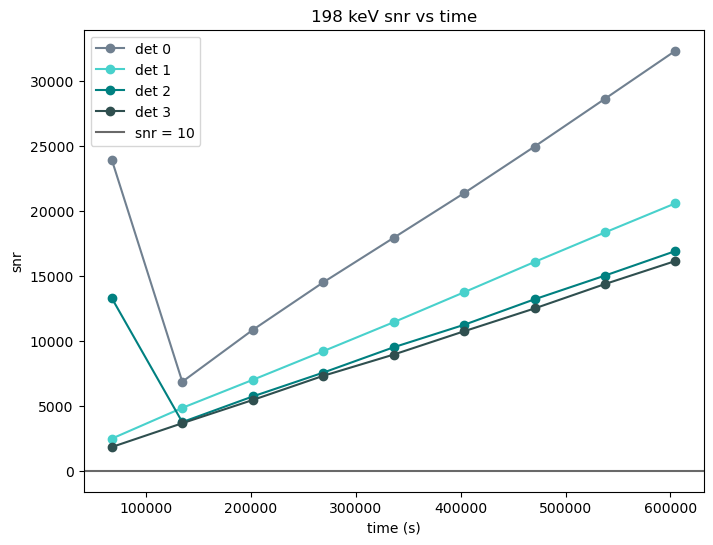

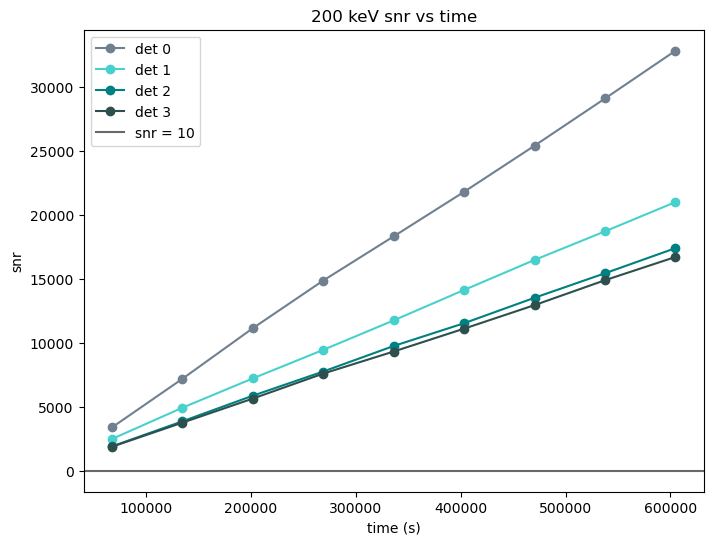

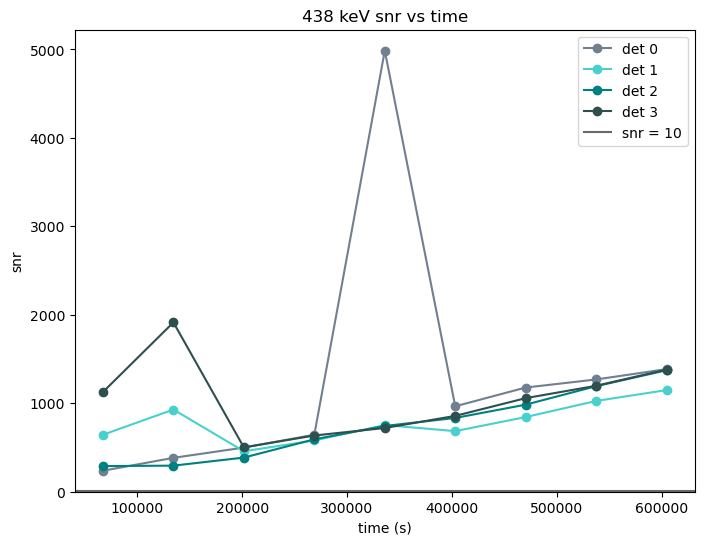

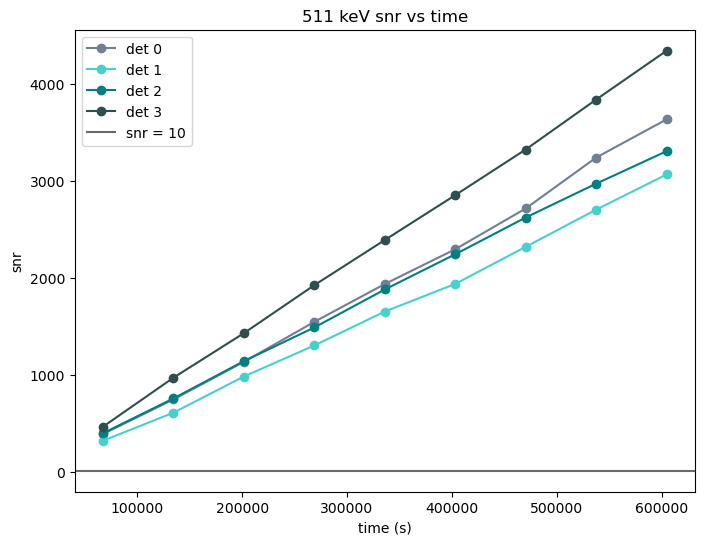

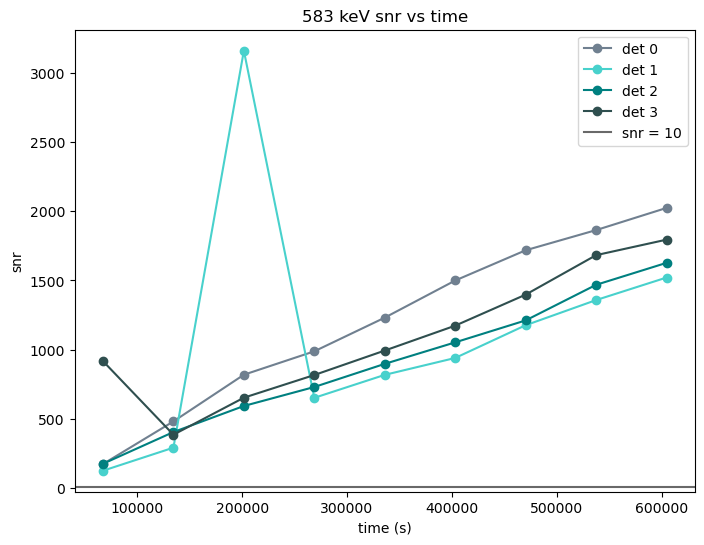

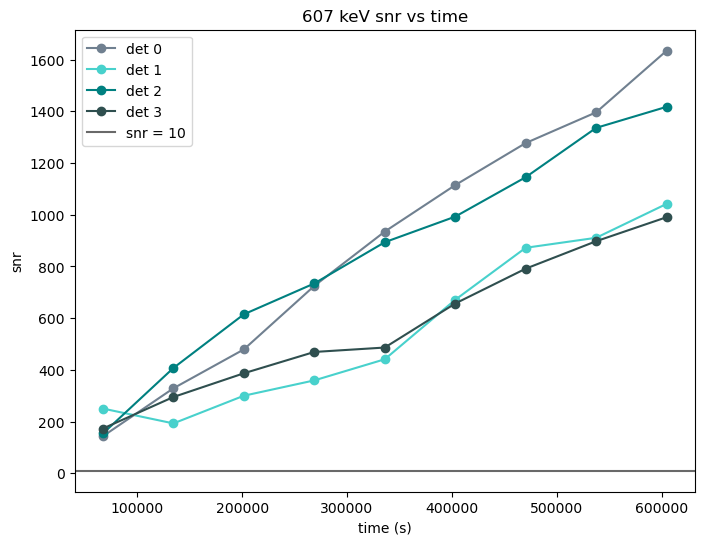

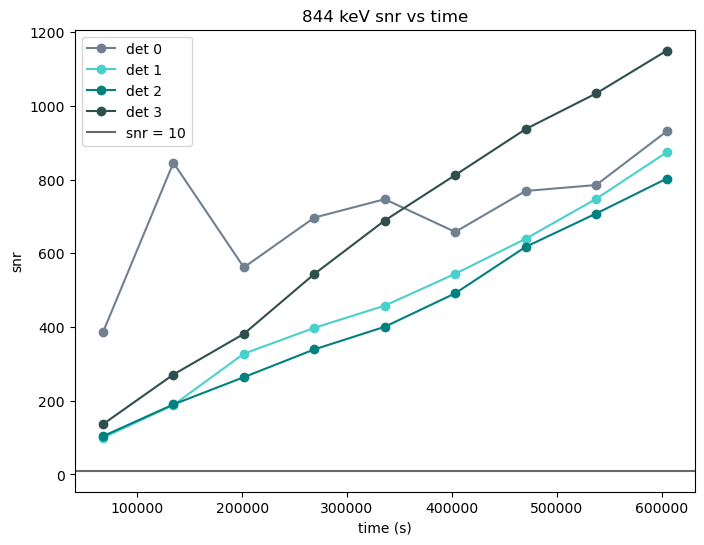

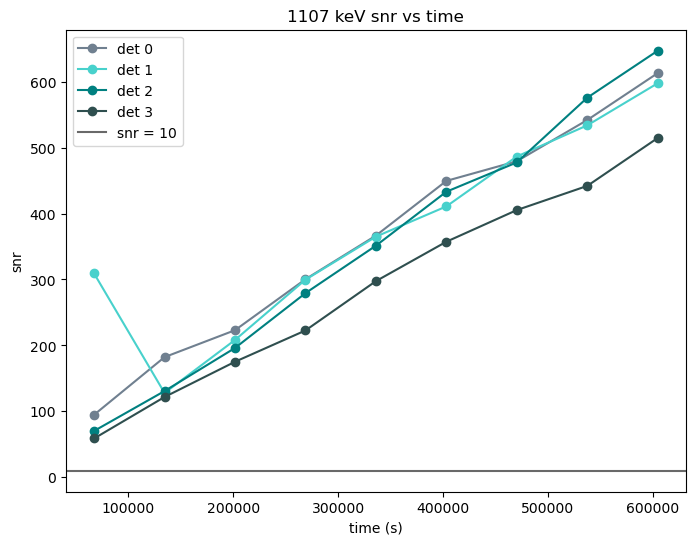

In [ ]:
#recreating the snr with time graphs from anaya's paper
time = df['Time[s]'].to_numpy()
energy = df['Energy'].to_numpy()
detector_id = df['Detector ID'].to_numpy()
bins = 200
fitting_window = 10
points = 10

benchmarks = np.linspace(df['Time[s]'].min(), df['Time[s]'].max(), points)
colors = {0: 'slategray', 1: 'mediumturquoise', 2: 'teal', 3: 'darkslategray'}

for line in [198, 200, 438, 511, 583, 607, 844, 1107, 1369]:
    lower_bound, upper_bound, _, _ = get_bounds(line)
    _, _, fitted_lower, fitted_upper = get_bounds(line, fitting_window=fitting_window)
    plt.figure(figsize=(8, 6))
    
    for det_id in np.arange(0, 4, 1):
        snr_per_detector = []
        
        for benchmark in benchmarks:
            time_mask = (time <= benchmark) & (detector_id == det_id)
            energy_mask = energy[time_mask]
            
            counts, bin_edges, bin_width, bin_centers = bin_sorting(bins, energy_mask, lower_bound, upper_bound)
            slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
            peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
            popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
            snr_val = snr(popt, counts, bin_width)
             
            snr_per_detector.append(snr_val)

        plt.plot(benchmarks, snr_per_detector, color = colors[det_id], marker='o', label=f'det {det_id}')
        
    plt.axhline(y = 10, color = 'dimgrey', label = 'snr = 10')
    plt.title(f"{line} keV snr vs time")
    plt.xlabel('time (s)')
    plt.ylabel('snr')
    plt.legend()
    plt.show()

In [ ]:
#new df!!
stored_values_simdata = []
centroid_vals = {93:93.311, 175:174.956, 198:198.394, 438:438.634, 596:595.847, 1107:1107.016}
bins = 200
fitting_window = 10
sigma_window = 1.4

for line in [93, 175, 198, 438, 596, 1107]:
    lower_bound, upper_bound, _, _ = get_bounds(line)
    counts, bin_edges, bin_width, bin_centers = bin_sorting(bins, energy, lower_bound, upper_bound)
    slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
    _, _, fitted_lower, fitted_upper = get_bounds(line, fitting_window=fitting_window)
    peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
    popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
    snr_val = snr(popt, bin_width, sigma_window = sigma_window)
    
    row = {
        "line": line,
        "bins": bins, 
        "fitting_window": fitting_window, 
        "bin_width": bin_width,  
        "A_over_A_err": popt[4] / p_err[4], 
        "snr": snr_val
        }
    #storing all 80 rows into my empty list
    stored_values_simdata.append(row)
            
#step 4: now i need to put them in a df
stored_values_simdata_df = pd.DataFrame(stored_values_simdata)

stored_values_simdata_df.to_csv("/Users/laurencadle/spurs_2026/stored_values_simdata.csv", index=False)
stored_values_simdata_df.head(10)